# MacSentinel 01 · macOS Telemetry Exploration

## tl;dr

The fixture contains six multi-step attack stories alongside benign user and administrator behavior. The analysis checks class balance, telemetry coverage, and the event patterns that will later drive detection models.

## Goal

Understand the structure, limitations, and observable signals in normalized macOS Endpoint Security-style telemetry.

**Safety and scope:** all events are deterministic synthetic fixtures. Reserved `.example` domains and inert filenames are used; this project does not execute payloads, collect private data, or bypass platform controls.


## Setup

Load the shared synthetic macOS telemetry fixture and dependency-light visualization helpers. The data source and seed are explicit so every result can be reproduced offline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from macsentinel.core import *
from macsentinel.visuals import *

SEED = 42
DATA_PATH = Path("macsentinel/data/synthetic_macos_events.csv")
events = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
FIGURES = []
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print(f"Loaded {len(events):,} synthetic events across {events.session_id.nunique():,} sessions and {events.host_id.nunique()} hosts.")


Loaded 2,520 synthetic events across 420 sessions and 30 hosts.


## Steps

### 1. Validate source, grain, and coverage


In [2]:
coverage = pd.Series({
    "events": len(events),
    "sessions": events.session_id.nunique(),
    "hosts": events.host_id.nunique(),
    "users": events.user_hash.nunique(),
    "attack_sessions": events.loc[events.label.eq(1), "session_id"].nunique(),
    "missing_required_values": int(events[["timestamp", "host_id", "session_id", "process", "event_type", "label"]].isna().sum().sum()),
})
print(coverage.to_string())
assert coverage["missing_required_values"] == 0
assert events.event_id.is_unique


events                     2520
sessions                    420
hosts                        30
users                       119
attack_sessions              75
missing_required_values       0


### 2. Profile scenarios and event types


Sessions by scenario:
 scenario
benign                     345
launchagent_persistence     20
download_execute            15
data_exfiltration           14
credential_access           11
ransomware_burst             8
gatekeeper_bypass            7

Event mix by scenario:
 event_type               auth  exec  file_delete  file_read  file_write  gatekeeper_bypass  network_connect
scenario                                                                                                   
benign                    188   517            0        523         360                  0              482
credential_access           0    33            0         22           0                  0               11
data_exfiltration           0    14           14         14          14                  0               28
download_execute            0    30            0          0          30                  0               30
gatekeeper_bypass           0    14            0          0           7       

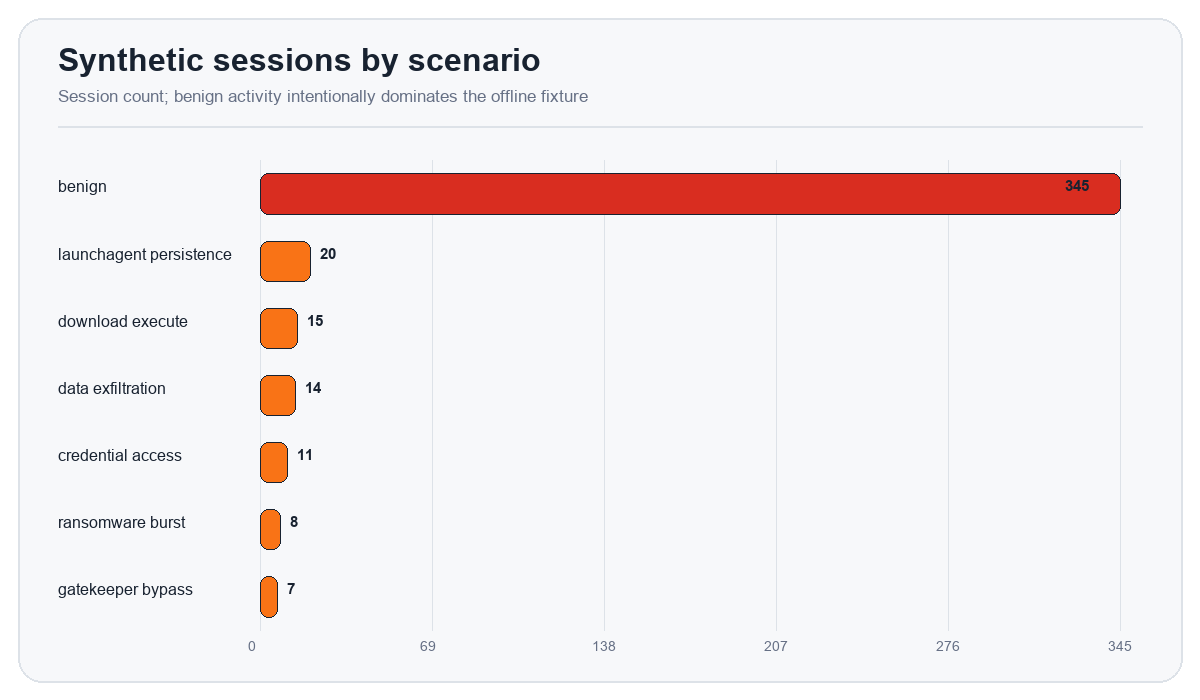

In [3]:
scenario_sessions = events.groupby("scenario").session_id.nunique().sort_values(ascending=False)
event_mix = pd.crosstab(events.scenario, events.event_type)
print("Sessions by scenario:\n", scenario_sessions.to_string())
print("\nEvent mix by scenario:\n", event_mix.to_string())

figure = bar_chart(
    scenario_sessions.index,
    scenario_sessions.values,
    "Synthetic sessions by scenario",
    "Session count; benign activity intentionally dominates the offline fixture",
)
FIGURES.append(figure)
figure


## Visual Insights & ML Extension

### 3. Compare observable signal coverage


                         gatekeeper_bypass  xprotect_detection  privilege_escalation  persistence_write  sensitive_access  network_beacon
scenario                                                                                                                                 
download_execute                         0                   8                    12                  0                 0              15
launchagent_persistence                  0                   0                    20                 40                 0               0
gatekeeper_bypass                        5                   0                     0                  0                 0               7
credential_access                        0                   0                     0                  0                22              11
ransomware_burst                         0                   0                     0                  0                 0               0
data_exfiltration                 

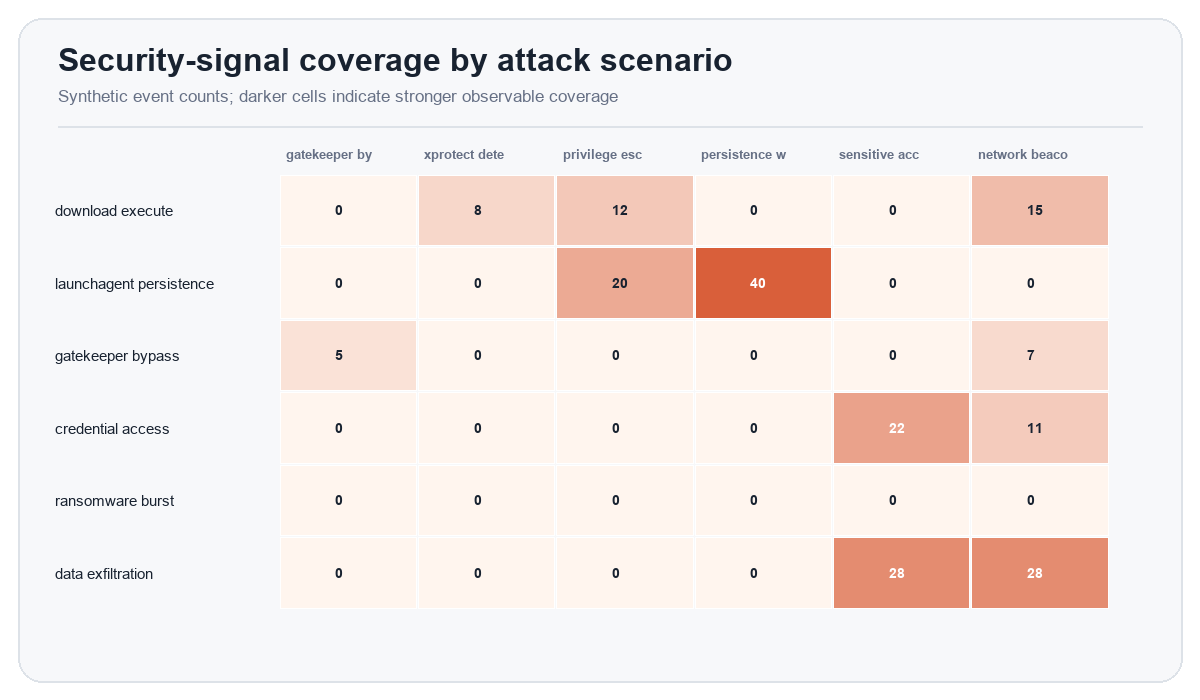

In [4]:
signal_columns = ["gatekeeper_bypass", "xprotect_detection", "privilege_escalation", "persistence_write", "sensitive_access", "network_beacon"]
signal_matrix = events.groupby("scenario")[signal_columns].sum().reindex([name for name in SCENARIOS if name != "benign"]).fillna(0)
print(signal_matrix.astype(int).to_string())

figure = matrix_chart(
    signal_matrix.to_numpy(),
    signal_matrix.index,
    [name.replace("_", " ") for name in signal_columns],
    "Security-signal coverage by attack scenario",
    "Synthetic event counts; darker cells indicate stronger observable coverage",
)
FIGURES.append(figure)
figure


### 4. Inspect event volume over time


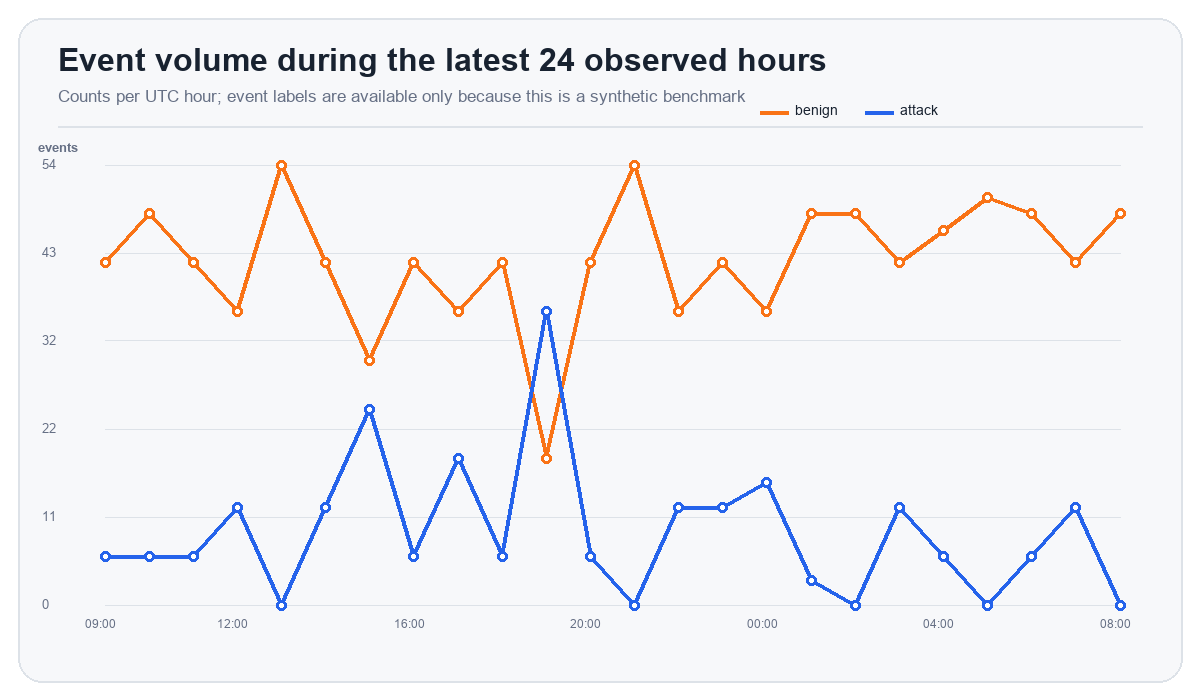

In [5]:
timeline = (
    events.assign(hour=events.timestamp.dt.floor("h"))
    .groupby(["hour", "label"]).size().unstack(fill_value=0)
    .rename(columns={0: "benign", 1: "attack"})
)
for column in ["benign", "attack"]:
    if column not in timeline:
        timeline[column] = 0
timeline = timeline.tail(24)
figure = line_chart(
    [stamp.strftime("%H:%M") for stamp in timeline.index],
    {"benign": timeline["benign"].to_numpy(), "attack": timeline["attack"].to_numpy()},
    "Event volume during the latest 24 observed hours",
    "Counts per UTC hour; event labels are available only because this is a synthetic benchmark",
    "events",
)
FIGURES.append(figure)
figure


## Checks


In [6]:
assert set(events.scenario.unique()) == set(SCENARIOS)
assert events.groupby("session_id").size().eq(6).all()
assert events.timestamp.dt.tz is not None
assert events.data_source.eq("synthetic macOS Endpoint Security-style fixture").all()
print("PASS: schema, session grain, timezone, scenario coverage, and synthetic-source labels are valid.")


PASS: schema, session grain, timezone, scenario coverage, and synthetic-source labels are valid.


## Next Steps

- Replace the fixture reader with an authorized `eslogger` normalization adapter.
- Keep pseudonymous user/host identifiers and avoid file-content collection.
- Preserve the synthetic fixture as a deterministic regression suite.
